------------------------OLD BELOW-----------------------------

In [ ]:
bin_timehorizon = "1 hour"
# bin_timehorizon = "15 minutes"

In [ ]:
# ==========================================
# STEP 3: Clean & Bucket Time
# ==========================================
print("Step 3: Cleaning edges and creating 15-min buckets...")
con.execute(f"""
    CREATE OR REPLACE TABLE edges_cleaned AS
    SELECT 
        -- Unique ID: ASD_UT_Intercity
        from_station || '_' || to_station || '_' || "Service:Type" AS unique_id,
        
        -- Time Bucket: Floor to nearest bin interval
        time_bucket(INTERVAL '{bin_timehorizon}', CAST(arrival_time AS TIMESTAMP)) AS time_idx,
        
        -- Impute Delay: 60 mins if cancelled, else actual delay
        CASE 
            WHEN is_cancelled = true THEN 60.0 
            ELSE COALESCE(arrival_delay, 0.0) 
        END AS delay_value,
        
        -- Extract Service Type for static feature later
        "Service:Type" as service_type
    FROM edges_raw
    WHERE to_station IS NOT NULL;
""")

Step 3: Cleaning edges and creating 15-min buckets...


In [ ]:
# ==========================================
# STEP 4: Build the "Skeleton" (Master Grid)
# ==========================================
print("Step 4: Generating the master time-series skeleton...")

# 4a. Get all unique IDs
con.execute("CREATE OR REPLACE TABLE distinct_ids AS SELECT DISTINCT unique_id, service_type FROM edges_cleaned")

# 4b. Get the full time range (Min to Max)
con.execute(f"""
    CREATE OR REPLACE TABLE all_times AS 
    SELECT generate_series(
        (SELECT MIN(time_idx) FROM edges_cleaned), 
        (SELECT MAX(time_idx) FROM edges_cleaned), 
        INTERVAL '{bin_timehorizon}'
    ) AS time_idx
""")

# 4c. Cartesian Product (Cross Join)
con.execute("""
    CREATE OR REPLACE TABLE skeleton AS
    SELECT 
        t.time_idx, 
        i.unique_id,
        i.service_type -- Keep static features in the skeleton
    FROM all_times t 
    CROSS JOIN distinct_ids i
""")

Step 4: Generating the master time-series skeleton...


RuntimeError: Query interrupted

In [ ]:
# ==========================================
# STEP 5: Aggregate Observations
# ==========================================
print("Step 5: Aggregating observations per bucket...")
con.execute("""
    CREATE OR REPLACE TABLE observations_agg AS
    SELECT 
        unique_id,
        time_idx,
        MAX(delay_value) as max_delay,
        COUNT(*) as traffic_volume
    FROM edges_cleaned
    GROUP BY 1, 2
""")

In [ ]:
# ==========================================
# STEP 6: Final Merge & Export
# ==========================================
print("Step 6: Merging and exporting...")
con.execute("""
    CREATE OR REPLACE TABLE final_dataset AS
    SELECT 
        s.time_idx,
        s.unique_id,
        
        -- Target: Fill gaps with 0.0
        COALESCE(o.max_delay, 0.0) AS target_delay,
        
        -- Dynamic Covariate: Fill gaps with 0 volume
        COALESCE(o.traffic_volume, 0) AS traffic_volume,
        
        -- Static Covariate
        s.service_type
        
    FROM skeleton s
    LEFT JOIN observations_agg o 
        ON s.time_idx = o.time_idx 
        AND s.unique_id = o.unique_id
    ORDER BY s.unique_id, s.time_idx
""")

In [ ]:
# Check final data
print(con.execute("SELECT * FROM final_dataset LIMIT 10").df())

# (OLD STATIONS TIME SERIES DATA) Creating full time series dataset

### Creating main time range foundation

First we create the start and end hourly time range (we also add numerical representations for sin/cos transformations later)

NOTE time range is currenlty based on services where we utilize arrival_time as bounds, but could use service_date instead if needed (which essentially adds some empty hours at the start and end, but is prob more straightforward time range)

In [ ]:
# --- Cell: Step 1 - Create Time Spine with Calendar Features ---

print("Creating continuous hourly timeline with calendar features...")

# We use a Common Table Expression (CTE) 'series' to generate the list first,
# then we select from it to calculate the extra columns easily.

create_main_query = """
    CREATE OR REPLACE TABLE timetable_main AS
    WITH bounds AS (
        SELECT 
            date_trunc('hour', MIN(arrival_time)) as start_time,
            date_trunc('hour', MAX(arrival_time)) as end_time
        FROM services
    ),
    raw_series AS (
        SELECT 
            UNNEST(GENERATE_SERIES(start_time, end_time, INTERVAL 1 HOUR)) as hour_bin
        FROM bounds
    )
    SELECT 
        hour_bin,
        -- Extract Time Features (Numerical)
        HOUR(hour_bin) as hour_of_day,      -- 0 to 23
        ISODOW(hour_bin) as day_of_week,    -- 1 (Monday) to 7 (Sunday)
        MONTH(hour_bin) as month_of_year    -- 1 to 12
    FROM raw_series
    ORDER BY hour_bin
"""

con.execute(create_main_query)


# Converting time zone info
convert_tz_query = """
    ALTER TABLE timetable_main 
    ALTER COLUMN hour_bin TYPE TIMESTAMP
"""

con.execute(convert_tz_query)

# --- Verification ---
print("✅ Table 'timetable_main' created.")
print(con.execute("SELECT * FROM timetable_main LIMIT 5").df())

# Check total range
check_query = """
    SELECT 
        MIN(hour_bin) as start, 
        MAX(hour_bin) as end, 
        COUNT(*) as total_hours
    FROM timetable_main
"""
print("\nRange Statistics:")
print(con.execute(check_query).df())

Creating continuous hourly timeline with calendar features...
✅ Table 'timetable_main' created.
             hour_bin  hour_of_day  day_of_week  month_of_year
0 2019-01-01 02:00:00            2            2              1
1 2019-01-01 03:00:00            3            2              1
2 2019-01-01 04:00:00            4            2              1
3 2019-01-01 05:00:00            5            2              1
4 2019-01-01 06:00:00            6            2              1

Range Statistics:
                start                 end  total_hours
0 2019-01-01 02:00:00 2025-01-01 02:00:00        52609


In [ ]:
# This shows Column Name, Column Type, Nullable, etc.
con.sql(f"DESCRIBE SELECT * FROM timetable_main").show()
# This gives you stats per column, including missing values (null_percentage)
con.sql(f"SUMMARIZE SELECT * FROM timetable_main").show()

┌───────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│  column_name  │ column_type │  null   │   key   │ default │  extra  │
│    varchar    │   varchar   │ varchar │ varchar │ varchar │ varchar │
├───────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ hour_bin      │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ hour_of_day   │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ day_of_week   │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ month_of_year │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
└───────────────┴─────────────┴─────────┴─────────┴─────────┴─────────┘

┌───────────────┬─────────────┬─────────────────────┬─────────────────────┬───────────────┬─────────────────────┬────────────────────┬─────────────────────┬─────────────────────┬─────────────────────┬───────┬─────────────────┐
│  column_name  │ column_type │         min         │         max         │ approx_unique │         avg         │        std

### Adding Station Cross Join

Note/todo we currently use all stations present in the stations dataset, cuz currently when filtering on only stations present in the services (non ghost stations) it seems that we disconnect the graph somehow

In [ ]:
# --- Cell: Step 2 - Create Spatio-Temporal Grid ---

print("Step 2: Expanding timeline to all stations (Cross Join)...")

# We take the timetable (with calendar features) and multiply it by every active station.
create_grid_query = """
    CREATE OR REPLACE TABLE timetable_grid AS
    SELECT 
        t.hour_bin,
        -- Carry over the calendar features we created in Step 1
        t.hour_of_day,
        t.day_of_week,
        t.month_of_year,
        
        -- The Station Column
        s.code as station_code,
        s.type as station_type
        
    FROM timetable_main t
    CROSS JOIN stations s
    ORDER BY t.hour_bin, s.code
"""

con.execute(create_grid_query)

# --- Verification ---
# The total rows should be: (Total Hours) * (Total Stations)
stats_query = """
    SELECT 
        (SELECT COUNT(*) FROM timetable_main) as total_hours,
        (SELECT COUNT(*) FROM stations) as total_stations,
        COUNT(*) as grid_rows
    FROM timetable_grid
"""
stats = con.execute(stats_query).df()

print("✅ Table 'timetable_grid' created.")
display(stats)

# Quick sanity check: Did the math work?
expected = stats['total_hours'][0] * stats['total_stations'][0]
actual = stats['grid_rows'][0]

if expected == actual:
    print(f"Verified: Grid size is correct ({actual:,} rows).")
else:
    print(f"⚠️ Mismatch! Expected {expected:,} but got {actual:,}")

Step 2: Expanding timeline to all stations (Cross Join)...
✅ Table 'timetable_grid' created.


,total_hours,total_stations,grid_rows
0,52609,397,20885773


Verified: Grid size is correct (20,885,773 rows).


### Adding services

In [ ]:
# --- Cell: Step 3 - Populate Grid with Actual Data ---

print("Step 3: Joining actual services and filling gaps...")


con.execute("""
    CREATE OR REPLACE TABLE hourly_stats AS
    
    WITH actuals AS (
        -- 1. Aggregating the raw services first
        -- This compresses millions of train rows into (Hour x Station) summaries
        SELECT 
            date_trunc('hour', arrival_time) as hour_bin,
            station_code,
            
            -- Metrics
            COUNT(*) as total_trains,
            SUM(CASE WHEN arrival_delay_min > 0 THEN 1 ELSE 0 END) as delayed_trains_count,
            ROUND(SUM(arrival_delay_min), 1) as total_delay_minutes,
            ROUND(AVG(arrival_delay_min), 1) as avg_delay_minutes
            
        FROM services
        WHERE arrival_time IS NOT NULL 
          AND is_cancelled = false 
        GROUP BY 1, 2
    )
    
    SELECT 
        -- 2. Select everything from our Grid (The Spine)
        grid.hour_bin,
        grid.station_code,
        grid.hour_of_day,
        grid.day_of_week,
        grid.month_of_year,
        
        -- 3. Bring in the Actuals, filling gaps with 0
        COALESCE(act.total_trains, 0) as total_trains,
        COALESCE(act.delayed_trains_count, 0) as delayed_trains_count,
        COALESCE(act.total_delay_minutes, 0) as total_delay_minutes,
        
        -- Special handling for Average: 
        -- If 0 trains ran, average delay is technically undefined, but 0 is safe for ML.
        COALESCE(act.avg_delay_minutes, 0) as avg_delay_minutes
        
    FROM timetable_grid grid
    LEFT JOIN actuals act 
        ON grid.hour_bin = act.hour_bin 
        AND grid.station_code = act.station_code
    ORDER BY grid.hour_bin, grid.station_code
""")

# --- Verification ---
print("✅ Table 'hourly_stats' created successfully.")

# Check 1: Verify a busy time (Utrecht Centraal at 8 AM)
print("\n--- Check: Busy Hour (Should have data) ---")
busy_check = """
    SELECT * FROM hourly_stats 
    WHERE station_code = 'UT' AND hour_of_day = 8 
    LIMIT 3
"""
display(con.execute(busy_check).df())

# Check 2: Verify a quiet time (Utrecht Centraal at 4 AM)
# This confirms that our COALESCE logic worked (should see 0s, not NULLs)
print("\n--- Check: Quiet Hour (Should be 0, not NULL) ---")
quiet_check = """
    SELECT * FROM hourly_stats 
    WHERE station_code = 'UT' AND hour_of_day = 4 
    LIMIT 3
"""
display(con.execute(quiet_check).df())

Step 3: Joining actual services and filling gaps...
✅ Table 'hourly_stats' created successfully.

--- Check: Busy Hour (Should have data) ---


,hour_bin,station_code,hour_of_day,day_of_week,month_of_year,total_trains,delayed_trains_count,total_delay_minutes,avg_delay_minutes
0,2019-01-01 08:00:00,UT,8,2,1,34,13.0,60.0,1.8
1,2019-01-02 08:00:00,UT,8,3,1,58,16.0,42.0,0.7
2,2019-01-03 08:00:00,UT,8,4,1,60,10.0,26.0,0.4



--- Check: Quiet Hour (Should be 0, not NULL) ---


,hour_bin,station_code,hour_of_day,day_of_week,month_of_year,total_trains,delayed_trains_count,total_delay_minutes,avg_delay_minutes
0,2019-01-01 04:00:00,UT,4,2,1,1,0.0,0.0,0.0
1,2019-01-02 04:00:00,UT,4,3,1,1,1.0,3.0,3.0
2,2019-01-03 04:00:00,UT,4,4,1,1,0.0,0.0,0.0


### Adding disruptions

In [ ]:
# --- Cell: Step 4 - Add Disruption Features ---

print("Step 4: Merging disruption events into the timeline...")

con.execute("""
    CREATE OR REPLACE TABLE hourly_stats_enriched AS
    
    WITH 
    -- 1. Prepare Disruptions (Ensure we have the flattened view from earlier)
    flat_disruptions AS (
        SELECT 
            UNNEST(station_array) as station_code,
            start_time,
            end_time,
            cause_nl
        FROM disruptions -- Utilizing the view we created in the Quality Check step
        WHERE duration_minutes > 0
    ),
    
    -- 2. Aggregate Disruptions per Hour/Station
    -- (A station might have 2 separate disruptions in one hour)
    hourly_disruptions AS (
        SELECT 
            h.hour_bin,
            h.station_code,
            -- Count how many distinct disruption events touch this hour
            COUNT(d.start_time) as disruption_count,
            -- Boolean flag: Was there ANY disruption?
            MAX(CASE WHEN d.start_time IS NOT NULL THEN 1 ELSE 0 END) as is_disrupted
        FROM hourly_stats h
        LEFT JOIN flat_disruptions d
          ON h.station_code = d.station_code
          -- Overlap Logic: The disruption overlaps with the hour bin
          AND d.start_time < (h.hour_bin + INTERVAL 1 HOUR)
          AND d.end_time > h.hour_bin
        GROUP BY 1, 2
    )
    
    -- 3. Join back to main table
    SELECT 
        base.*,
        COALESCE(d.disruption_count, 0) as disruption_count,
        CAST(COALESCE(d.is_disrupted, 0) as BOOLEAN) as is_disrupted
    FROM hourly_stats base
    LEFT JOIN hourly_disruptions d
        ON base.hour_bin = d.hour_bin 
        AND base.station_code = d.station_code
    ORDER BY base.hour_bin, base.station_code
""")

# --- Verification ---
print("✅ Table 'hourly_stats_enriched' created.")

# Check: Show me an hour with a disruption
print("\n--- Sample: Disrupted Hours ---")
check_query = """
    SELECT hour_bin, station_code, total_trains, avg_delay_minutes, is_disrupted
    FROM hourly_stats_enriched
    WHERE is_disrupted = TRUE
    LIMIT 5
"""
display(con.execute(check_query).df())

Step 4: Merging disruption events into the timeline...
✅ Table 'hourly_stats_enriched' created.

--- Sample: Disrupted Hours ---


,hour_bin,station_code,total_trains,avg_delay_minutes,is_disrupted
0,2019-01-01 06:00:00,GDM,0,0.0,True
1,2019-01-01 07:00:00,ALMO,0,0.0,True
2,2019-01-01 08:00:00,ALMO,0,0.0,True
3,2019-01-01 08:00:00,CL,5,6.6,True
4,2019-01-01 08:00:00,EML,3,1.3,True


### Adding weather data

In [ ]:
# --- Cell: Step 5 - Add Detailed Weather Features ---

print("Step 5: Integrating detailed weather data and calculating lag features...")

con.execute("""
    CREATE OR REPLACE TABLE hourly_stats_final AS
    
    WITH 
    -- 1. Clean & Aggregate Weather to Hourly level as some report by some minor deviations
    weather_hourly AS (
        SELECT
            station_code,
            -- Truncate weather timestamp to the hour to match hour_bin
            DATE_TRUNC('hour', "time") as weather_hour,
            
            -- [Instant Variables] -> Average them for the hour block
            AVG(temperature_2m) as temp_c,
            AVG(wind_speed_10m) as wind_speed_kmh,
            AVG(soil_temperature_0_to_7cm) as soil_temp_c,
            AVG(snow_depth) as snow_depth_m,
            
            -- [Max/Gusts] -> Maximum observed in the hour
            MAX(wind_gusts_10m) as wind_gust_kmh,
            
            -- [Accumulated Variables] -> Sum them (Preceding hour sum)
            COALESCE(SUM(rain), 0) as rain_mm,
            COALESCE(SUM(snowfall), 0) as snow_cm,
            
            -- Boolean Flag: Was there any precipitation this hour? Either raining or snowing
            MAX(CASE WHEN rain > 0 OR snowfall > 0 THEN 1 ELSE 0 END) as is_precipitating_int
        FROM raw_weather
        GROUP BY 1, 2
    ),
    
    -- 2. Add Time-Series Features (Lag Logic)
    weather_features AS (
        SELECT 
            *,
            -- Convert integer flag to boolean for readability
            CAST(is_precipitating_int AS BOOLEAN) as is_precipitating,
            
            -- Feature: "Rain Started This Hour"
            -- (True if raining NOW, but was NOT raining PREVIOUS hour)
            CASE 
                WHEN is_precipitating_int = 1 
                     AND LAG(is_precipitating_int, 1, 0) OVER (PARTITION BY station_code ORDER BY weather_hour) = 0 
                THEN TRUE
                ELSE FALSE
            END as rain_started_this_hour
            
        FROM weather_hourly
    )
    
    -- 3. Join with the Disruption-Enriched Data
    SELECT 
        base.*,
        
        -- Weather Columns (Safe defaults for missing data)
        COALESCE(w.temp_c, 0) as temp_c,
        COALESCE(w.soil_temp_c, 0) as soil_temp_c,
        COALESCE(w.wind_speed_kmh, 0) as wind_speed_kmh,
        COALESCE(w.wind_gust_kmh, 0) as wind_gust_kmh,
        
        COALESCE(w.rain_mm, 0) as rain_mm,
        COALESCE(w.snow_cm, 0) as snow_cm,
        COALESCE(w.snow_depth_m, 0) as snow_depth_m,
        
        COALESCE(w.is_precipitating, FALSE) as is_precipitating,
        COALESCE(w.rain_started_this_hour, FALSE) as rain_started_this_hour
        
    FROM hourly_stats_enriched base
    LEFT JOIN weather_features w
        ON base.hour_bin = w.weather_hour 
        AND base.station_code = w.station_code
    ORDER BY base.hour_bin, base.station_code
""")

# --- Verification ---
print("✅ Table 'hourly_stats_final' created with all weather variables.")

# Check: Show me an hour with snow or high wind
print("\n--- Sample: Extreme Weather Hours ---")
check_query = """
    SELECT hour_bin, station_code, temp_c, snow_cm, wind_gust_kmh, soil_temp_c
    FROM hourly_stats_final
    WHERE snow_cm > 0 OR wind_gust_kmh > 40
    LIMIT 5
"""
display(con.execute(check_query).df())

Step 5: Integrating detailed weather data and calculating lag features...
✅ Table 'hourly_stats_final' created with all weather variables.

--- Sample: Extreme Weather Hours ---


,hour_bin,station_code,temp_c,snow_cm,wind_gust_kmh,soil_temp_c
0,2019-01-01 02:00:00,AKM,7.6175,0.0,43.919998,7.9175
1,2019-01-01 02:00:00,ALMB,7.8805,0.0,41.039997,7.8805
2,2019-01-01 02:00:00,ALMO,7.8935,0.0,41.039997,7.8935
3,2019-01-01 02:00:00,ALMP,7.9000,0.0,41.039997,7.9000
4,2019-01-01 02:00:00,AMR,8.2370,0.0,47.880001,8.1370


In [ ]:
# Check: Show me an hour where rain started
print("\n--- Sample: Rain Onset Events ---")
check_query = """
    SELECT *
    FROM hourly_stats_final
    LIMIT 5
"""
display(con.execute(check_query).df())


--- Sample: Rain Onset Events ---


,hour_bin,station_code,hour_of_day,day_of_week,month_of_year,total_trains,delayed_trains_count,total_delay_minutes,avg_delay_minutes,disruption_count,is_disrupted,temp_c,soil_temp_c,wind_speed_kmh,wind_gust_kmh,rain_mm,snow_cm,snow_depth_m,is_precipitating,rain_started_this_hour
0,2019-01-01 02:00:00,AC,2,2,1,0,0.0,0.0,0.0,0,False,8.087001,7.8370,21.542923,36.719997,0.0,0.0,0.0,False,False
1,2019-01-01 02:00:00,AH,2,2,1,0,0.0,0.0,0.0,0,False,7.361000,7.7110,19.813087,36.360001,0.0,0.0,0.0,False,False
2,2019-01-01 02:00:00,AHP,2,2,1,0,0.0,0.0,0.0,0,False,7.439000,7.7890,19.813087,36.360001,0.0,0.0,0.0,False,False
3,2019-01-01 02:00:00,AHPR,2,2,1,0,0.0,0.0,0.0,0,False,7.491000,7.8410,19.813087,36.360001,0.0,0.0,0.0,False,False
4,2019-01-01 02:00:00,AHZ,2,2,1,0,0.0,0.0,0.0,0,False,7.484500,7.8345,19.191748,35.639999,0.0,0.0,0.0,False,False


### Adding Holidays data (could be moved earlier for speed)

In [ ]:
# --- Cell: Step 6 - Add Calendar, NS Rush Hour & Holiday Features ---

print("Step 6: Integrating Holidays table and applying NS-specific Rush Hour/Weekend logic...")

con.execute("""
    CREATE OR REPLACE TABLE training_data_complete AS
    
    SELECT 
        t.*,
        
        -- 1. Holiday Integration
        -- Join on the DATE part of the timestamp
        CASE 
            WHEN h.holiday_name IS NOT NULL THEN TRUE 
            ELSE FALSE 
        END as is_holiday,
        
        -- 3. NS Specific Weekend Definition
        -- Definition: Friday 18:30 to Monday 04:00
        CASE 
            -- Friday (5) from 18:00 onwards (covers the 18:30 start)
            WHEN EXTRACT('dow' FROM t.hour_bin) = 5 AND EXTRACT('hour' FROM t.hour_bin) >= 18 THEN TRUE
            -- Saturday (6) and Sunday (0) are always weekend
            WHEN EXTRACT('dow' FROM t.hour_bin) IN (0, 6) THEN TRUE
            -- Monday (1) before 04:00
            WHEN EXTRACT('dow' FROM t.hour_bin) = 1 AND EXTRACT('hour' FROM t.hour_bin) < 4 THEN TRUE
            ELSE FALSE
        END as is_weekend,
        
        -- 4. NS Specific Rush Hour Definition
        -- Definition: Weekdays 06:30-09:00 and 16:00-18:30
        -- Note: Excludes Weekends (Sat/Sun) and Holidays (usually treated as Sunday schedule)
        CASE 
            -- If it's the weekend or a holiday, it is NOT rush hour
            WHEN (EXTRACT('dow' FROM t.hour_bin) IN (0, 6)) OR (h.holiday_name IS NOT NULL) THEN FALSE
            
            -- Morning Peak: 06:30 - 09:00
            -- Includes hour 6 (06:30 start), 7, 8. Excludes 9 (ends 09:00).
            WHEN EXTRACT('hour' FROM t.hour_bin) IN (6, 7, 8) THEN TRUE
            
            -- Evening Peak: 16:00 - 18:30
            -- Includes hour 16, 17, 18 (ends 18:30).
            WHEN EXTRACT('hour' FROM t.hour_bin) IN (16, 17, 18) THEN TRUE
            
            ELSE FALSE 
        END as is_rush_hour

    FROM hourly_stats_final t
    -- Left Join to Holidays Table on the specific date
    LEFT JOIN raw_holidays h
        ON CAST(t.hour_bin AS DATE) = CAST(h.date AS DATE)
    
    ORDER BY t.hour_bin, t.station_code
""")

# --- Verification ---
print("✅ Table 'training_data_complete' created.")

# Check 1: Verify Holiday Match
print("\n--- Sample: Holiday Matches ---")
check_holidays = """
    SELECT CAST(hour_bin AS DATE) as date, is_holiday, is_rush_hour
    FROM training_data_complete
    WHERE is_holiday = TRUE
    LIMIT 3
"""
display(con.execute(check_holidays).df())


Step 6: Integrating Holidays table and applying NS-specific Rush Hour/Weekend logic...
✅ Table 'training_data_complete' created.

--- Sample: Holiday Matches ---


,date,is_holiday,is_rush_hour
0,2019-01-01,True,False
1,2019-01-01,True,False
2,2019-01-01,True,False



--- Sample: Friday Evening Transition (Weekend Start) ---


,hour_bin,day_of_week,hour_of_day,is_weekend
0,2019-01-04 16:00:00,5,16,False
1,2019-01-04 16:00:00,5,16,False
2,2019-01-04 16:00:00,5,16,False
3,2019-01-04 16:00:00,5,16,False
4,2019-01-04 16:00:00,5,16,False


In [ ]:
# Check 2: Verify NS Weekend Logic (Friday Evening)
print("\n--- Sample: Friday Evening Transition (Weekend Start) ---")
check_weekend = """
    SELECT hour_bin, day_of_week, hour_of_day, is_weekend, is_rush_hour
    FROM training_data_complete
    WHERE day_of_week = 5 AND hour_of_day BETWEEN 16 AND 20
    LIMIT 5
"""
display(con.execute(check_weekend).df())


--- Sample: Friday Evening Transition (Weekend Start) ---


,hour_bin,day_of_week,hour_of_day,is_weekend,is_rush_hour
0,2019-01-04 16:00:00,5,16,False,True
1,2019-01-04 16:00:00,5,16,False,True
2,2019-01-04 16:00:00,5,16,False,True
3,2019-01-04 16:00:00,5,16,False,True
4,2019-01-04 16:00:00,5,16,False,True


### Adding station connections

In [ ]:
#todo gnn only probs

## Save full dataset

In [ ]:
# --- Cell: Split Data by Year (Rolling Window) ---

print("Assigning Train/Validation/Test splits based on last 2 years...")

# 1. Add the split column (if not exists)
try:
    con.execute("ALTER TABLE training_data_complete ADD COLUMN dataset_group VARCHAR")
except:
    pass # Column might already exist

# 2. Update based on the MAX date in your dataset
# Logic: 
#   - Test:       [Max Date - 1 Year]  to  [Max Date]
#   - Validation: [Max Date - 2 Years] to  [Max Date - 1 Year]
#   - Train:      Everything older
split_query = """
    UPDATE training_data_complete
    SET dataset_group = CASE
        -- The Test Set (The most recent 1 year)
        WHEN hour_bin >= (SELECT MAX(hour_bin) - INTERVAL 1 YEAR FROM training_data_complete) 
            THEN 'test'
        
        -- The Validation Set (The year before that)
        WHEN hour_bin >= (SELECT MAX(hour_bin) - INTERVAL 2 YEAR FROM training_data_complete) 
            THEN 'validation'
            
        -- The Training Set (Everything else)
        ELSE 'train'
    END
"""

con.execute(split_query)

# --- Verification ---
# It is CRITICAL to verify the start/end dates for each group
stats_query = """
    SELECT 
        dataset_group,
        COUNT(*) as rows,
        MIN(hour_bin) as start_date,
        MAX(hour_bin) as end_date,
        
        -- Calculate rough duration in days to verify
        DATE_DIFF('day', MIN(hour_bin), MAX(hour_bin)) as duration_days
    FROM training_data_complete
    GROUP BY dataset_group
    ORDER BY MIN(hour_bin)
"""
display(con.execute(stats_query).df())

print("✅ Splits assigned. Ready to save.")

Assigning Train/Validation/Test splits based on last 2 years...


,dataset_group,rows,start_date,end_date,duration_days
0,train,13920408,2019-01-01 02:00:00,2023-01-01 01:00:00,1461
1,validation,3477720,2023-01-01 02:00:00,2024-01-01 01:00:00,365
2,test,3487645,2024-01-01 02:00:00,2025-01-01 02:00:00,366


✅ Splits assigned. Ready to save.


In [ ]:
import os

print("Saving final training data to Parquet...")

# 1. Define the directory
# (Assuming filtered_output_root_folder is defined earlier, e.g., "data/")
full_dataset_dir = os.path.join(filtered_output_root_folder, "full_dataset")

# 2. Create the folder if it doesn't exist
os.makedirs(full_dataset_dir, exist_ok=True)

# 3. Define the full target file path
# This handles the slashes for you automatically
target_file = os.path.join(full_dataset_dir, "training_data_final.parquet")

print(f"Target path: {target_file}")

# 4. Save
# We inject the complete 'target_file' path into the query
save_query = f"""
    COPY training_data_complete 
    TO '{target_file}' 
    (FORMAT PARQUET, COMPRESSION SNAPPY, OVERWRITE_OR_IGNORE true)
"""

con.execute(save_query)
print("✅ File saved successfully.")

Saving final training data to Parquet...
Target path: c:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\MSc-Thesis\Bao\downloads\data\filtered\full_dataset\training_data_final.parquet
✅ File saved successfully.


In [ ]:
import os

print("Saving training data partitioned by split...")

full_dataset_dir = os.path.join(filtered_output_root_folder, "full_dataset_partitioned")
os.makedirs(full_dataset_dir, exist_ok=True)

# Note the 'PARTITION_BY' clause
con.execute(f"""
    COPY training_data_complete 
    TO '{full_dataset_dir}' 
    (FORMAT PARQUET, COMPRESSION SNAPPY, PARTITION_BY dataset_group, OVERWRITE_OR_IGNORE true)
""")

print(f"✅ Successfully saved partitioned data to: {full_dataset_dir}")

Saving training data partitioned by split...
✅ Successfully saved partitioned data to: c:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\MSc-Thesis\Bao\downloads\data\filtered\full_dataset_partitioned


In [ ]:
# This returns a DataFrame with column_name, column_type, null, key, default, and extra
con.execute("DESCRIBE training_data_complete").df()

,column_name,column_type,null,key,default,extra
0,hour_bin,TIMESTAMP,YES,None,None,None
1,station_code,VARCHAR,YES,None,None,None
2,hour_of_day,BIGINT,YES,None,None,None
3,day_of_week,BIGINT,YES,None,None,None
4,month_of_year,BIGINT,YES,None,None,None
5,total_trains,BIGINT,YES,None,None,None
6,delayed_trains_count,HUGEINT,YES,None,None,None
7,total_delay_minutes,HUGEINT,YES,None,None,None
8,avg_delay_minutes,DOUBLE,YES,None,None,None
9,disruption_count,BIGINT,YES,None,None,None


In [ ]:
con.execute("""
    SELECT 
        station_code, 
        hour_bin, 
        COUNT(*) as count
    FROM training_data_complete
    GROUP BY station_code, hour_bin
    HAVING COUNT(*) > 1
    ORDER BY count DESC
    LIMIT 20
""").df()

,station_code,hour_bin,count


# (OLD IGNORE)

## Imports

In [ ]:
%matplotlib inline

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pathlib import Path
from tqdm import tqdm
import gzip

from darts import TimeSeries
from darts.utils.statistics import check_seasonality, extract_trend_and_seasonality, stationarity_test_kpss, plot_acf, plot_residuals_analysis


folder_path = Path("downloads/data")
services_file_path = os.path.join(folder_path, "NS-services/services.parquet")
disruptions_file_path = os.path.join(folder_path, "NS-disruptions/disruptions-2019.csv")
stations_file_path = os.path.join(folder_path, "NS-stations/stations-2023-09-nl.csv")
distances_file_path = os.path.join(folder_path, "NS-tariff-distances/tariff-distances-2022-01.csv")
ns_distances_file_path = os.path.join(folder_path, "NS-tariff-distances/tariff-distances-2022-01-ns-ns-international.csv")
holidays_file_path = os.path.join(folder_path, "holidays/dutch_holidays_2019_2025.parquet")
# weather_file_path = os.path.join(folder_path, "weather/weather_merged_all.parquet")
weather_file_path = os.path.join(folder_path, "weather/ns_stations_weather_2019.parquet")

services = pd.read_parquet(services_file_path)
holidays = pd.read_parquet(holidays_file_path)
disruptions = pd.read_csv(disruptions_file_path)
stations = pd.read_csv(stations_file_path)
distances = pd.read_csv(distances_file_path)
ns_distances = pd.read_csv(ns_distances_file_path)
weather = pd.read_parquet(weather_file_path)


FileNotFoundError: [Errno 2] No such file or directory: 'downloads\\data\\NS-services/services.parquet'

In [ ]:
services.head()


,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,Stop:Station name,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform
0,738804,2019-01-01,Intercity,NS,1410,False,False,1,6220112,RTD,Rotterdam Centraal,None,NaN,None,2019-01-01T02:00:00+01:00,1.0,False,True,3,2
1,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220116,DT,Delft,2019-01-01T02:12:00+01:00,0.0,False,2019-01-01T02:12:00+01:00,0.0,False,False,1,1
2,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220120,GV,Den Haag HS,2019-01-01T02:20:00+01:00,1.0,False,2019-01-01T02:21:00+01:00,1.0,False,False,6,6
3,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220124,LEDN,Leiden Centraal,2019-01-01T02:35:00+01:00,0.0,False,2019-01-01T02:45:00+01:00,0.0,False,False,5b,5b
4,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220128,SHL,Schiphol Airport,2019-01-01T03:00:00+01:00,0.0,False,2019-01-01T03:02:00+01:00,0.0,False,False,3,3


In [ ]:
services.describe()

,Service:RDT-ID,Service:Train number,Service:Maximum delay,Stop:RDT-ID,Stop:Arrival delay,Stop:Departure delay
count,3.916300e+04,39163.000000,39163.000000,3.916300e+04,35459.000000,35469.000000
mean,6.262097e+06,5984.481117,0.192503,5.590201e+07,0.617220,0.657137
std,4.033942e+06,17816.215960,1.311634,3.655504e+07,2.274406,2.144581
min,7.388040e+05,123.000000,0.000000,6.220112e+06,-8.000000,-6.000000
25%,3.108209e+06,3030.000000,0.000000,2.699512e+07,0.000000,0.000000
50%,5.562391e+06,4631.000000,0.000000,4.923475e+07,0.000000,0.000000
75%,1.036809e+07,6620.000000,0.000000,9.307157e+07,0.000000,0.000000
max,1.269197e+07,703938.000000,80.000000,1.144828e+08,80.000000,80.000000


In [ ]:
services.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39163 entries, 0 to 39162
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Service:RDT-ID                39163 non-null  int64  
 1   Service:Date                  39163 non-null  object 
 2   Service:Type                  39163 non-null  object 
 3   Service:Company               39163 non-null  object 
 4   Service:Train number          39163 non-null  int64  
 5   Service:Completely cancelled  39163 non-null  bool   
 6   Service:Partly cancelled      39163 non-null  bool   
 7   Service:Maximum delay         39163 non-null  int64  
 8   Stop:RDT-ID                   39163 non-null  int64  
 9   Stop:Station code             39163 non-null  object 
 10  Stop:Station name             39163 non-null  object 
 11  Stop:Arrival time             35459 non-null  object 
 12  Stop:Arrival delay            35459 non-null  float64
 13  S

Check total services date range should be 2019-01 till 2024-12

In [ ]:
import pandas as pd

services['Service:Date'] = pd.to_datetime(services['Service:Date'])

min_date = services['Service:Date'].min()
max_date = services['Service:Date'].max()
duration = max_date - min_date

print(f"Start Date (min): {min_date}")
print(f"End Date (max):   {max_date}")
print(f"Total Duration:   {duration}")


Start Date (min): 2019-01-01 00:00:00
End Date (max):   2024-01-01 00:00:00
Total Duration:   1826 days 00:00:00


(TEMP) Checking subset range

In [ ]:
services_2019 = services[services['Service:Date'].dt.year == 2019]

if not services_2019.empty:
    min_date = services_2019['Service:Date'].min()
    max_date = services_2019['Service:Date'].max()
    duration = max_date - min_date

    print(f"Start Date (2019): {min_date}")
    print(f"End Date (2019):   {max_date}")
    print(f"Total Duration:    {duration}")
else:
    print("No records found for the year 2019.")

Start Date (2019): 2019-01-01 00:00:00
End Date (2019):   2019-01-01 00:00:00
Total Duration:    0 days 00:00:00


In [ ]:
holidays.head()

,date,holiday_name,year,day_of_week
0,2019-01-01,Nieuwjaarsdag,2019,Tuesday
1,2019-04-19,Goede Vrijdag,2019,Friday
2,2019-04-21,Eerste paasdag,2019,Sunday
3,2019-04-22,Tweede paasdag,2019,Monday
4,2019-04-27,Koningsdag,2019,Saturday


In [ ]:
holidays.describe()

,date,year
count,72,72.000000
mean,2022-06-11 18:20:00,2022.013889
min,2019-01-01 00:00:00,2019.000000
25%,2020-05-31 18:00:00,2020.000000
50%,2022-05-11 12:00:00,2022.000000
75%,2024-03-31 06:00:00,2024.000000
max,2025-12-26 00:00:00,2025.000000
std,NaN,2.031395


In [ ]:
holidays.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          72 non-null     datetime64[ns]
 1   holiday_name  72 non-null     object        
 2   year          72 non-null     int32         
 3   day_of_week   72 non-null     object        
dtypes: datetime64[ns](1), int32(1), object(2)
memory usage: 2.1+ KB


In [ ]:
disruptions.head()

,rdt_id,ns_lines,rdt_lines,rdt_lines_id,rdt_station_names,rdt_station_codes,cause_nl,cause_en,statistical_cause_nl,statistical_cause_en,cause_group,start_time,end_time,duration_minutes
0,25236,Utrecht-'s-Hertogenbosch,'s-Hertogenbosch - Utrecht Centraal,151,"Geldermalsen,'s-Hertogenbosch,Zaltbommel","GDM, HT, ZBM",defecte bovenleiding,damaged overhead wires,defecte bovenleiding,damaged overhead wires,infrastructure,2019-01-01 06:32:16,2019-01-01 06:33:31,1.0
1,25237,Almere-Lelystad; Almere-Lelystad; Hoofddorp-Sc...,"Almere Oostvaarders - Utrecht Centraal, Amster...","144,145,149","Almere Oostvaarders,Lelystad Centrum","ALMO, LLS",vandalisme,vandalism,vandalisme,vandalism,external,2019-01-01 07:12:00,2019-01-01 09:53:48,162.0
2,25238,Amersfoort-Zwolle,Amersfoort - Zwolle,48,"Ermelo,Harderwijk,Putten","EML, HD, PT",seinstoring,signal failure,seinstoring,signal failure,infrastructure,2019-01-01 08:26:58,2019-01-01 08:44:01,17.0
3,25239,Utrecht-'s-Hertogenbosch; Utrecht-Tiel,"'s-Hertogenbosch - Utrecht Centraal, Tiel - Ut...","150,151","Culemborg,Geldermalsen,Houten Castellum","CL, GDM, HTNC",inzet van hulpdiensten,an emergency call,inzet van hulpdiensten,an emergency call,external,2019-01-01 08:36:00,2019-01-01 09:09:43,34.0
4,25240,Amersfoort-Zwolle,Amersfoort - Zwolle,48,"Amersfoort Centraal,Amersfoort Schothorst,Amer...","AMF, AMFS, AVAT, EML, HD, HDE, NKK, NS, PT, WZ...",herstelwerkzaamheden,repair works,herstelwerkzaamheden,repair works,engineering work,2019-01-01 09:45:48,2019-01-01 12:47:54,182.0


In [ ]:
disruptions.describe()

,rdt_id,duration_minutes
count,5940.000000,5937.000000
mean,28205.500000,96.943069
std,1714.874631,297.367167
min,25236.000000,0.000000
25%,26720.750000,12.000000
50%,28205.500000,40.000000
75%,29690.250000,113.000000
max,31175.000000,17011.000000


In [ ]:
disruptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5940 entries, 0 to 5939
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   rdt_id                5940 non-null   int64  
 1   ns_lines              5940 non-null   object 
 2   rdt_lines             5936 non-null   object 
 3   rdt_lines_id          5936 non-null   object 
 4   rdt_station_names     5939 non-null   object 
 5   rdt_station_codes     5939 non-null   object 
 6   cause_nl              5940 non-null   object 
 7   cause_en              5940 non-null   object 
 8   statistical_cause_nl  5940 non-null   object 
 9   statistical_cause_en  5940 non-null   object 
 10  cause_group           5940 non-null   object 
 11  start_time            5940 non-null   object 
 12  end_time              5937 non-null   object 
 13  duration_minutes      5937 non-null   float64
dtypes: float64(1), int64(1), object(12)
memory usage: 649.8+ KB


from disruptions we could use start_time as boolean one hot encoding to indicate a MAJOR disruption has caused the delay

if needed categorize cause_en or utilize rdt's cause_group?

In [ ]:
stations.head()

,id,code,uic,name_short,name_medium,name_long,slug,country,type,geo_lat,geo_lng
0,266,HT,8400319,Den Bosch,'s-Hertogenbosch,'s-Hertogenbosch,s-hertogenbosch,NL,knooppuntIntercitystation,51.690480,5.293620
1,269,HTO,8400320,Dn Bosch O,'s-Hertogenb. O.,'s-Hertogenbosch Oost,s-hertogenbosch-oost,NL,stoptreinstation,51.700554,5.318333
2,227,HDE,8400388,'t Harde,'t Harde,'t Harde,t-harde,NL,stoptreinstation,52.409168,5.893611
3,51,ATN,8400045,Aalten,Aalten,Aalten,aalten,NL,stoptreinstation,51.921327,6.578627
4,5,AC,8400047,Abcoude,Abcoude,Abcoude,abcoude,NL,stoptreinstation,52.278500,4.977000


In [ ]:
stations.describe()

,id,uic,geo_lat,geo_lng
count,397.000000,3.970000e+02,397.000000,397.000000
mean,315.503778,8.400380e+06,52.160612,5.524714
std,193.894114,2.047490e+02,0.602023,0.768896
min,5.000000,8.400045e+06,50.771946,3.595278
25%,157.000000,8.400200e+06,51.863154,4.878056
50%,304.000000,8.400362e+06,52.145279,5.573889
75%,456.000000,8.400553e+06,52.458611,6.057500
max,820.000000,8.400752e+06,53.458419,7.199370


In [ ]:
stations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           397 non-null    int64  
 1   code         396 non-null    object 
 2   uic          397 non-null    int64  
 3   name_short   397 non-null    object 
 4   name_medium  397 non-null    object 
 5   name_long    397 non-null    object 
 6   slug         397 non-null    object 
 7   country      397 non-null    object 
 8   type         397 non-null    object 
 9   geo_lat      397 non-null    float64
 10  geo_lng      397 non-null    float64
dtypes: float64(2), int64(2), object(7)
memory usage: 34.2+ KB


In [ ]:
distances.head()

,Station,AC,AH,AHP,AHPR,AHZ,AKL,AKM,ALM,ALMB,...,ZLSH,ZLW,ZP,ZTM,ZTMO,ZV,ZVB,ZVT,ZWD,ZZS
0,AC,XXX,82,83,85,90,71,188,32,38,...,116,106,106,63,62,96,114,42,89,28
1,AH,82,XXX,1,3,8,77,153,98,104,...,81,120,29,106,105,14,128,123,107,109
2,AHP,83,1,XXX,2,9,78,152,99,105,...,80,121,28,107,106,13,129,124,108,110
3,AHPR,85,3,2,XXX,11,80,150,101,107,...,78,123,26,109,108,15,131,126,110,112
4,AHZ,90,8,9,11,XXX,69,161,106,112,...,89,112,37,114,113,22,120,131,99,117


In [ ]:
distances.describe()

,Station,AC,AH,AHP,AHPR,AHZ,AKL,AKM,ALM,ALMB,...,ZLSH,ZLW,ZP,ZTM,ZTMO,ZV,ZVB,ZVT,ZWD,ZZS
count,398,399,399,399,399,399,399,399,399,399,...,399,399,399,399,399,399,399,399,399,399
unique,398,194,178,177,172,179,185,196,181,178,...,165,223,168,207,203,179,222,213,210,209
top,ZZS,42,119,90,122,99,80,181,53,59,...,127,138,129,72,65,103,122,75,98,136
freq,1,7,7,8,7,8,6,6,6,6,...,7,5,7,7,6,8,5,5,6,6


In [ ]:
distances.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Columns: 400 entries, Station to ZZS
dtypes: object(400)
memory usage: 1.2+ MB


In [ ]:
ns_distances.head()

,Station,AC,AH,AHP,AHPR,AHZ,AKL,AKM,ALM,ALMB,...,ZLSH,ZLW,ZP,ZTM,ZTMO,ZV,ZVB,ZVT,ZWD,ZZS
0,AC,XXX,82,83,85,90,?,188,32,38,...,?,106,111,63,62,96,114,42,89,28
1,AH,82,XXX,1,3,8,?,153,107,113,...,?,120,29,106,105,14,128,124,132,110
2,AHP,83,1,XXX,2,9,?,152,108,114,...,?,121,28,107,106,13,129,125,133,111
3,AHPR,85,3,2,XXX,11,?,150,110,116,...,?,123,26,109,108,15,131,127,135,113
4,AHZ,90,8,9,11,XXX,?,161,115,121,...,?,112,37,114,113,22,120,132,129,118


In [ ]:
ns_distances.describe()

,Station,AC,AH,AHP,AHPR,AHZ,AKL,AKM,ALM,ALMB,...,ZLSH,ZLW,ZP,ZTM,ZTMO,ZV,ZVB,ZVT,ZWD,ZZS
count,398,399,399,399,399,399,399,399,399,399,...,399,399,399,399,399,399,399,399,399,399
unique,398,143,136,136,144,135,2,163,153,145,...,2,152,143,157,151,136,151,160,154,163
top,ZZS,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,?
freq,1,135,135,135,135,135,398,135,135,135,...,398,135,135,135,135,135,135,135,135,135


In [ ]:
ns_distances.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Columns: 400 entries, Station to ZZS
dtypes: object(400)
memory usage: 1.2+ MB


In [ ]:
weather.head()

,time,station_code,station_name,latitude,longitude,temperature_2m,rain,snowfall,snow_depth,wind_speed_10m,wind_gusts_10m,soil_temperature_0_to_7cm
0,2019-01-01 00:00:00+00:00,HT,Den Bosch,51.69048,5.29362,7.337,0.0,0.0,0.0,17.072504,30.599998,7.937
1,2019-01-01 01:00:00+00:00,HT,Den Bosch,51.69048,5.29362,7.287,0.0,0.0,0.0,18.204042,32.399998,7.637
2,2019-01-01 02:00:00+00:00,HT,Den Bosch,51.69048,5.29362,7.387,0.0,0.0,0.0,18.792551,33.480000,7.487
3,2019-01-01 03:00:00+00:00,HT,Den Bosch,51.69048,5.29362,6.937,0.0,0.0,0.0,18.792551,33.480000,7.237
4,2019-01-01 04:00:00+00:00,HT,Den Bosch,51.69048,5.29362,7.037,0.0,0.0,0.0,19.829433,35.279999,7.137


In [ ]:
weather.describe()

,latitude,longitude,temperature_2m,rain,snowfall,snow_depth,wind_speed_10m,wind_gusts_10m,soil_temperature_0_to_7cm
count,19056.000000,19056.000000,19056.000000,19056.000000,19056.0,19056.0,19056.000000,19056.000000,19056.000000
mean,52.160612,5.524714,6.289156,0.011361,0.0,0.0,21.111765,39.479488,6.347823
std,0.601280,0.767948,1.655974,0.041597,0.0,0.0,7.127416,12.428456,1.186811
min,50.771946,3.595278,-1.737000,0.000000,0.0,0.0,4.802999,10.440001,1.463000
25%,51.863154,4.878056,5.471875,0.000000,0.0,0.0,16.870138,32.760002,5.587000
50%,52.145279,5.573889,6.387000,0.000000,0.0,0.0,21.188072,39.599998,6.387000
75%,52.458611,6.057500,7.448500,0.000000,0.0,0.0,25.148520,46.439999,7.363000
max,53.458419,7.199370,9.730500,0.400000,0.0,0.0,50.816135,88.919998,8.493500


In [ ]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19056 entries, 0 to 19055
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   time                       19056 non-null  datetime64[ns, UTC]
 1   station_code               19008 non-null  object             
 2   station_name               19056 non-null  object             
 3   latitude                   19056 non-null  float64            
 4   longitude                  19056 non-null  float64            
 5   temperature_2m             19056 non-null  float32            
 6   rain                       19056 non-null  float32            
 7   snowfall                   19056 non-null  float32            
 8   snow_depth                 19056 non-null  float32            
 9   wind_speed_10m             19056 non-null  float32            
 10  wind_gusts_10m             19056 non-null  float32            
 11  so

weather sanity check, lgtm 

In [ ]:
len(weather['station_name'].unique())

397

(TEMP) preprocess test for xgb/naive -> for now aggregated timeseries + filled, check jonathan/existing papers (ETA google)

In [ ]:
services.tail()

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,Stop:Station name,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform
39158,12691967,2024-01-01,Intercity,NS,2944,False,False,0,114318424,HNK,Hoorn Kersenboogerd,2024-01-01T15:03:00+01:00,0.0,False,2024-01-01T15:03:00+01:00,0.0,False,False,2,2
39159,12691967,2024-01-01,Intercity,NS,2944,False,False,0,114318425,HKS,Hoogkarspel,2024-01-01T15:10:00+01:00,0.0,False,2024-01-01T15:10:00+01:00,0.0,False,False,2,2
39160,12691967,2024-01-01,Intercity,NS,2944,False,False,0,114318426,BKG,Bovenkarspel-Grootebroek,2024-01-01T15:15:00+01:00,0.0,False,2024-01-01T15:17:00+01:00,0.0,False,False,1,1
39161,12691967,2024-01-01,Intercity,NS,2944,False,False,0,114318427,BKF,Bovenkarspel Flora,2024-01-01T15:19:00+01:00,0.0,False,2024-01-01T15:19:00+01:00,0.0,False,False,1,1
39162,12691967,2024-01-01,Intercity,NS,2944,False,False,0,114318428,EKZ,Enkhuizen,2024-01-01T15:23:00+01:00,0.0,False,None,NaN,None,False,1,1


Sorting arrival time

In [ ]:
# Ensure datetime with UTC
services["Stop:Arrival time"] = pd.to_datetime(services["Stop:Arrival time"], utc=True)

# Sort ascending
services = services.sort_values("Stop:Arrival time").reset_index(drop=True)

# RFC 3339 formatted column
services["Sorted Stop: Arrival time"] = (
    services["Stop:Arrival time"]
    .dt.strftime("%Y-%m-%dT%H:%M:%S%z")
    .str.replace(r'(\+|\-)(\d{2})(\d{2})$', r'\1\2:\3', regex=True)
)

services

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,...,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform,Sorted Stop: Arrival time
0,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220116,DT,...,2019-01-01 01:12:00+00:00,0.0,False,2019-01-01T02:12:00+01:00,0.0,False,False,1,1,2019-01-01T01:12:00+00:00
1,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220120,GV,...,2019-01-01 01:20:00+00:00,1.0,False,2019-01-01T02:21:00+01:00,1.0,False,False,6,6,2019-01-01T01:20:00+00:00
2,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220122,ASB,...,2019-01-01 01:34:00+00:00,0.0,False,2019-01-01T02:34:00+01:00,0.0,False,False,6,6,2019-01-01T01:34:00+00:00
3,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220124,LEDN,...,2019-01-01 01:35:00+00:00,0.0,False,2019-01-01T02:45:00+01:00,0.0,False,False,5b,5b,2019-01-01T01:35:00+00:00
4,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220125,ASD,...,2019-01-01 01:44:00+00:00,1.0,False,2019-01-01T02:46:00+01:00,2.0,False,False,2a,2a,2019-01-01T01:44:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39158,12691959,2024-01-01,Intercity,NS,3642,False,False,8,114318316,RSD,...,NaT,NaN,None,2024-01-01T11:57:00+01:00,0.0,False,False,3a,3a,NaN
39159,12691961,2024-01-01,Sprinter,NS,7341,False,False,1,114318337,BKL,...,NaT,NaN,None,2024-01-01T11:58:00+01:00,0.0,False,False,3,3,NaN
39160,12691962,2024-01-01,Sprinter,NS,6640,False,False,1,114318348,DDR,...,NaT,NaN,None,2024-01-01T11:58:00+01:00,0.0,False,False,4b,4b,NaN
39161,12691964,2024-01-01,Sprinter,NS,6040,False,False,2,114318381,HT,...,NaT,NaN,None,2024-01-01T11:59:00+01:00,0.0,False,False,4a,4a,NaN


In [ ]:
services.isna().sum()

Service:RDT-ID                     0
Service:Date                       0
Service:Type                       0
Service:Company                    0
Service:Train number               0
Service:Completely cancelled       0
Service:Partly cancelled           0
Service:Maximum delay              0
Stop:RDT-ID                        0
Stop:Station code                  0
Stop:Station name                  0
Stop:Arrival time               3704
Stop:Arrival delay              3704
Stop:Arrival cancelled          3704
Stop:Departure time             3694
Stop:Departure delay            3694
Stop:Departure cancelled        3694
Stop:Platform change               0
Stop:Planned platform            813
Stop:Actual platform             813
Sorted Stop: Arrival time       3704
dtype: int64

In [ ]:
services = services.dropna(subset=["Stop:Arrival time"]).reset_index(drop=True)

relevant_cols = ['Service:RDT-ID', 'Service:Train number', 'Stop:RDT-ID', 
 'Service:Date', 
#  'Service:Completely cancelled', 'Service:Partly cancelled', 
#  'Stop:Arrival cancelled',
 'Stop:Arrival delay', 'Stop:Arrival time', 
 'Sorted Stop: Arrival time']

In [ ]:
services['Service:RDT-ID'].nunique()

3704

In [ ]:
stations.head()

,id,code,uic,name_short,name_medium,name_long,slug,country,type,geo_lat,geo_lng
0,266,HT,8400319,Den Bosch,'s-Hertogenbosch,'s-Hertogenbosch,s-hertogenbosch,NL,knooppuntIntercitystation,51.690480,5.293620
1,269,HTO,8400320,Dn Bosch O,'s-Hertogenb. O.,'s-Hertogenbosch Oost,s-hertogenbosch-oost,NL,stoptreinstation,51.700554,5.318333
2,227,HDE,8400388,'t Harde,'t Harde,'t Harde,t-harde,NL,stoptreinstation,52.409168,5.893611
3,51,ATN,8400045,Aalten,Aalten,Aalten,aalten,NL,stoptreinstation,51.921327,6.578627
4,5,AC,8400047,Abcoude,Abcoude,Abcoude,abcoude,NL,stoptreinstation,52.278500,4.977000


In [ ]:
#  (TEMP) 2019 only 1 day of 1 year only due to timeseries gap in subset
services = services[services['Service:Date'].dt.year == 2019].reset_index(drop=True)
services

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,...,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform,Sorted Stop: Arrival time
0,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220116,DT,...,2019-01-01 01:12:00+00:00,0.0,False,2019-01-01T02:12:00+01:00,0.0,False,False,1,1,2019-01-01T01:12:00+00:00
1,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220120,GV,...,2019-01-01 01:20:00+00:00,1.0,False,2019-01-01T02:21:00+01:00,1.0,False,False,6,6,2019-01-01T01:20:00+00:00
2,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220122,ASB,...,2019-01-01 01:34:00+00:00,0.0,False,2019-01-01T02:34:00+01:00,0.0,False,False,6,6,2019-01-01T01:34:00+00:00
3,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220124,LEDN,...,2019-01-01 01:35:00+00:00,0.0,False,2019-01-01T02:45:00+01:00,0.0,False,False,5b,5b,2019-01-01T01:35:00+00:00
4,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220125,ASD,...,2019-01-01 01:44:00+00:00,1.0,False,2019-01-01T02:46:00+01:00,2.0,False,False,2a,2a,2019-01-01T01:44:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6793,739825,2019-01-01,Intercity,NS,3940,False,False,0,6236738,HKS,...,2019-01-01 13:07:00+00:00,0.0,False,2019-01-01T14:08:00+01:00,0.0,False,False,2,2,2019-01-01T13:07:00+00:00
6794,739798,2019-01-01,Intercity,NS,3941,False,False,0,6237096,HRL,...,2019-01-01 13:11:00+00:00,0.0,False,None,NaN,None,False,5,5,2019-01-01T13:11:00+00:00
6795,739825,2019-01-01,Intercity,NS,3940,False,False,0,6237025,BKG,...,2019-01-01 13:13:00+00:00,0.0,False,2019-01-01T14:16:00+01:00,0.0,False,False,1,1,2019-01-01T13:13:00+00:00
6796,739825,2019-01-01,Intercity,NS,3940,False,False,0,6237183,BKF,...,2019-01-01 13:18:00+00:00,0.0,False,2019-01-01T14:18:00+01:00,0.0,False,False,1,1,2019-01-01T13:18:00+00:00


In [ ]:
# Extract time bins
services['hour'] = services['Stop:Arrival time'].dt.hour
services['minute'] = services['Stop:Arrival time'].dt.minute

# quarter bins maybe for better precision? -> but async ts risk
services['quarter_hour_bin'] = (services['Stop:Arrival time'].dt.minute // 15) * 15
services

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,...,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform,Sorted Stop: Arrival time,hour,minute,quarter_hour_bin
0,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220116,DT,...,2019-01-01T02:12:00+01:00,0.0,False,False,1,1,2019-01-01T01:12:00+00:00,1,12,0
1,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220120,GV,...,2019-01-01T02:21:00+01:00,1.0,False,False,6,6,2019-01-01T01:20:00+00:00,1,20,15
2,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220122,ASB,...,2019-01-01T02:34:00+01:00,0.0,False,False,6,6,2019-01-01T01:34:00+00:00,1,34,30
3,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220124,LEDN,...,2019-01-01T02:45:00+01:00,0.0,False,False,5b,5b,2019-01-01T01:35:00+00:00,1,35,30
4,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220125,ASD,...,2019-01-01T02:46:00+01:00,2.0,False,False,2a,2a,2019-01-01T01:44:00+00:00,1,44,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6793,739825,2019-01-01,Intercity,NS,3940,False,False,0,6236738,HKS,...,2019-01-01T14:08:00+01:00,0.0,False,False,2,2,2019-01-01T13:07:00+00:00,13,7,0
6794,739798,2019-01-01,Intercity,NS,3941,False,False,0,6237096,HRL,...,None,NaN,None,False,5,5,2019-01-01T13:11:00+00:00,13,11,0
6795,739825,2019-01-01,Intercity,NS,3940,False,False,0,6237025,BKG,...,2019-01-01T14:16:00+01:00,0.0,False,False,1,1,2019-01-01T13:13:00+00:00,13,13,0
6796,739825,2019-01-01,Intercity,NS,3940,False,False,0,6237183,BKF,...,2019-01-01T14:18:00+01:00,0.0,False,False,1,1,2019-01-01T13:18:00+00:00,13,18,15


As service:date in services is the date scheduled arrival (delays do not affect it); we will use the start time of the disruption to determine on which date the disruption happened

In [ ]:
disruptions['disruption_date'] = pd.to_datetime(disruptions['start_time']).dt.date
disruptions

,rdt_id,ns_lines,rdt_lines,rdt_lines_id,rdt_station_names,rdt_station_codes,cause_nl,cause_en,statistical_cause_nl,statistical_cause_en,cause_group,start_time,end_time,duration_minutes,disruption_date
0,25236,Utrecht-'s-Hertogenbosch,'s-Hertogenbosch - Utrecht Centraal,151,"Geldermalsen,'s-Hertogenbosch,Zaltbommel","GDM, HT, ZBM",defecte bovenleiding,damaged overhead wires,defecte bovenleiding,damaged overhead wires,infrastructure,2019-01-01 06:32:16,2019-01-01 06:33:31,1.0,2019-01-01
1,25237,Almere-Lelystad; Almere-Lelystad; Hoofddorp-Sc...,"Almere Oostvaarders - Utrecht Centraal, Amster...","144,145,149","Almere Oostvaarders,Lelystad Centrum","ALMO, LLS",vandalisme,vandalism,vandalisme,vandalism,external,2019-01-01 07:12:00,2019-01-01 09:53:48,162.0,2019-01-01
2,25238,Amersfoort-Zwolle,Amersfoort - Zwolle,48,"Ermelo,Harderwijk,Putten","EML, HD, PT",seinstoring,signal failure,seinstoring,signal failure,infrastructure,2019-01-01 08:26:58,2019-01-01 08:44:01,17.0,2019-01-01
3,25239,Utrecht-'s-Hertogenbosch; Utrecht-Tiel,"'s-Hertogenbosch - Utrecht Centraal, Tiel - Ut...","150,151","Culemborg,Geldermalsen,Houten Castellum","CL, GDM, HTNC",inzet van hulpdiensten,an emergency call,inzet van hulpdiensten,an emergency call,external,2019-01-01 08:36:00,2019-01-01 09:09:43,34.0,2019-01-01
4,25240,Amersfoort-Zwolle,Amersfoort - Zwolle,48,"Amersfoort Centraal,Amersfoort Schothorst,Amer...","AMF, AMFS, AVAT, EML, HD, HDE, NKK, NS, PT, WZ...",herstelwerkzaamheden,repair works,herstelwerkzaamheden,repair works,engineering work,2019-01-01 09:45:48,2019-01-01 12:47:54,182.0,2019-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5935,31171,Breda-'s-Hertogenbosch,"'s-Hertogenbosch - Tilburg, Breda - Tilburg","68,69","Breda,Gilze-Rijen,'s-Hertogenbosch,Tilburg,Til...","BD, GZ, HT, TB, TBR, TBU",wisselstoring,points failure,wisselstoring,points failure,infrastructure,2019-12-31 08:07:52,2019-12-31 10:30:12,142.0,2019-12-31
5936,31172,Amersfoort-Deventer,Amersfoort - Apeldoorn,50,"Amersfoort Centraal,Apeldoorn","AMF, APD",aanrijding,collision,aanrijding,collision,accidents,2019-12-31 08:33:02,2019-12-31 09:49:44,77.0,2019-12-31
5937,31173,Utrecht-Amersfoort,Amersfoort - Utrecht Centraal,134,"Amersfoort Centraal,Bilthoven,Den Dolder,Utrec...","AMF, BHV, DLD, UT, UTO",aanrijding,collision,aanrijding,collision,accidents,2019-12-31 08:36:50,2019-12-31 10:29:48,113.0,2019-12-31
5938,31174,Amersfoort-Deventer,Amersfoort - Apeldoorn,50,"Amersfoort Centraal,Apeldoorn","AMF, APD",aanrijding,collision,aanrijding,collision,accidents,2019-12-31 09:12:56,2019-12-31 12:02:55,170.0,2019-12-31


In [ ]:
disruptions['cause_nl'].value_counts()

cause_nl
defecte trein                   2314
gestrande trein                  531
seinstoring                      434
wisselstoring                    340
aanrijding met een persoon       316
                                ... 
de bouw van een tunnel             1
de inzet van ander materieel       1
rijp aan de bovenleiding           1
te grote vertraging                1
acties in het buitenland           1
Name: count, Length: 70, dtype: int64

In [ ]:
disruptions['cause_group'].value_counts()

cause_group
rolling stock       2967
infrastructure      1383
accidents            588
external             506
logistical           218
engineering work     175
weather               61
unknown               25
staff                 17
Name: count, dtype: int64

In [ ]:
weather['date'] = pd.to_datetime(weather['time']).dt.date
weather['hour'] = pd.to_datetime(weather['time']).dt.hour
weather

,time,station_code,station_name,latitude,longitude,temperature_2m,rain,snowfall,snow_depth,wind_speed_10m,wind_gusts_10m,soil_temperature_0_to_7cm,date,hour
0,2019-01-01 00:00:00+00:00,HT,Den Bosch,51.69048,5.29362,7.337,0.0,0.0,0.0,17.072504,30.599998,7.937,2019-01-01,0
1,2019-01-01 01:00:00+00:00,HT,Den Bosch,51.69048,5.29362,7.287,0.0,0.0,0.0,18.204042,32.399998,7.637,2019-01-01,1
2,2019-01-01 02:00:00+00:00,HT,Den Bosch,51.69048,5.29362,7.387,0.0,0.0,0.0,18.792551,33.480000,7.487,2019-01-01,2
3,2019-01-01 03:00:00+00:00,HT,Den Bosch,51.69048,5.29362,6.937,0.0,0.0,0.0,18.792551,33.480000,7.237,2019-01-01,3
4,2019-01-01 04:00:00+00:00,HT,Den Bosch,51.69048,5.29362,7.037,0.0,0.0,0.0,19.829433,35.279999,7.137,2019-01-01,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19051,2019-01-02 19:00:00+00:00,ZLSH,Stadshagen,52.52764,6.05146,3.550,0.0,0.0,0.0,10.799999,18.000000,4.600,2019-01-02,19
19052,2019-01-02 20:00:00+00:00,ZLSH,Stadshagen,52.52764,6.05146,4.200,0.0,0.0,0.0,9.826088,19.440001,4.650,2019-01-02,20
19053,2019-01-02 21:00:00+00:00,ZLSH,Stadshagen,52.52764,6.05146,4.000,0.0,0.0,0.0,8.942214,16.919998,4.700,2019-01-02,21
19054,2019-01-02 22:00:00+00:00,ZLSH,Stadshagen,52.52764,6.05146,4.250,0.0,0.0,0.0,10.440000,17.280001,4.750,2019-01-02,22


## Merging Datasets

### Missing values

In [ ]:
print(f'Missing values in services : {services.isna().sum()}')
print(f'Missing values in holidays: {holidays.isna().sum()}')
print(f'Missing values in disruptions : {disruptions.isna().sum()}')
print(f'Missing values in stations : {stations.isna().sum()}')
print(f'Missing values in distances: {distances.isna().sum()}')
print(f'Missing values in ns_distances: {ns_distances.isna().sum()}')
print(f'Missing values in weather: {weather.isna().sum()}')

Missing values in services : Service:RDT-ID                    0
Service:Date                      0
Service:Type                      0
Service:Company                   0
Service:Train number              0
Service:Completely cancelled      0
Service:Partly cancelled          0
Service:Maximum delay             0
Stop:RDT-ID                       0
Stop:Station code                 0
Stop:Station name                 0
Stop:Arrival time                 0
Stop:Arrival delay                0
Stop:Arrival cancelled            0
Stop:Departure time             702
Stop:Departure delay            702
Stop:Departure cancelled        702
Stop:Platform change              0
Stop:Planned platform             0
Stop:Actual platform              0
Sorted Stop: Arrival time         0
hour                              0
minute                            0
quarter_hour_bin                  0
dtype: int64
Missing values in holidays: date            0
holiday_name    0
year            0
day_of_week 

### Merging all 3 datasets ns operation (services, stations, disruptions), weather and holiday dataset

In [ ]:
service_with_stations_data = pd.merge(services, stations, left_on=['Stop:Station code'], right_on=['code'], how='left')


In [ ]:
service_with_stations_data.head()
service_with_stations_data

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,...,code,uic,name_short,name_medium,name_long,slug,country,type,geo_lat,geo_lng
0,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220116,DT,...,DT,8400170.0,Delft,Delft,Delft,delft,NL,knooppuntIntercitystation,52.006668,4.356389
1,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220120,GV,...,GV,8400280.0,Dn Haag HS,Den Haag HS,Den Haag HS,den-haag-hs,NL,knooppuntIntercitystation,52.069721,4.322500
2,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220122,ASB,...,ASB,8400074.0,Bijlmer A,Bijlmer ArenA,Amsterdam Bijlmer ArenA,amsterdam-bijlmer-arena,NL,knooppuntStoptreinstation,52.312222,4.946944
3,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220124,LEDN,...,LEDN,8400390.0,Leiden C,Leiden C.,Leiden Centraal,leiden-centraal,NL,knooppuntIntercitystation,52.166111,4.481667
4,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220125,ASD,...,ASD,8400058.0,Amsterdm C,Amsterdam C.,Amsterdam Centraal,amsterdam-centraal,NL,megastation,52.378887,4.900278
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6793,739825,2019-01-01,Intercity,NS,3940,False,False,0,6236738,HKS,...,HKS,8400334.0,Hoogkrspl,Hoogkarspel,Hoogkarspel,hoogkarspel,NL,stoptreinstation,52.690556,5.183889
6794,739798,2019-01-01,Intercity,NS,3941,False,False,0,6237096,HRL,...,HRL,8400307.0,Heerlen,Heerlen,Heerlen,heerlen,NL,knooppuntIntercitystation,50.890835,5.975000
6795,739825,2019-01-01,Intercity,NS,3940,False,False,0,6237025,BKG,...,BKG,8400127.0,Bovenk-Gr,Bovenkarspel-Gr.,Bovenkarspel-Grootebroek,bovenkarspel-grootebroek,NL,stoptreinstation,52.695000,5.237778
6796,739825,2019-01-01,Intercity,NS,3940,False,False,0,6237183,BKF,...,BKF,8400230.0,Bovenk Flo,Bovenkarspel Fl.,Bovenkarspel Flora,bovenkarspel-flora,NL,stoptreinstation,52.696110,5.252778


In [ ]:
service_with_stations_data['hour']

0        1
1        1
2        1
3        1
4        1
        ..
6793    13
6794    13
6795    13
6796    13
6797    13
Name: hour, Length: 6798, dtype: int32

In [ ]:
service_with_stations_data['Stop:Arrival delay'].isna().sum()

np.int64(0)

In [ ]:
service_with_stations_data['Service:Date'] = pd.to_datetime(service_with_stations_data['Service:Date']).dt.date


ns_operation_data = pd.merge(service_with_stations_data, disruptions, left_on=['Service:RDT-ID', 'Service:Date'], right_on=['rdt_id', 'disruption_date'], how='left')
ns_operation_data

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,...,rdt_station_codes,cause_nl,cause_en,statistical_cause_nl,statistical_cause_en,cause_group,start_time,end_time,duration_minutes,disruption_date
0,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220116,DT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220120,GV,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220122,ASB,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220124,LEDN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220125,ASD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6793,739825,2019-01-01,Intercity,NS,3940,False,False,0,6236738,HKS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6794,739798,2019-01-01,Intercity,NS,3941,False,False,0,6237096,HRL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6795,739825,2019-01-01,Intercity,NS,3940,False,False,0,6237025,BKG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6796,739825,2019-01-01,Intercity,NS,3940,False,False,0,6237183,BKF,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
ns_operation_with_weather = pd.merge(ns_operation_data, weather, left_on=['Stop:Station code', 'Service:Date', 'hour'], right_on=['station_code', 'date', 'hour'], how='left')
ns_operation_with_weather

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,...,latitude,longitude,temperature_2m,rain,snowfall,snow_depth,wind_speed_10m,wind_gusts_10m,soil_temperature_0_to_7cm,date
0,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220116,DT,...,52.006668,4.356389,7.693500,0.0,0.0,0.0,18.584509,35.279999,7.743500,2019-01-01
1,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220120,GV,...,52.069721,4.322500,7.961000,0.0,0.0,0.0,22.148045,41.399998,7.761000,2019-01-01
2,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220122,ASB,...,52.312222,4.946944,8.059000,0.0,0.0,0.0,21.434364,37.439999,7.809000,2019-01-01
3,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220124,LEDN,...,52.166111,4.481667,8.267500,0.0,0.0,0.0,24.967499,43.919998,7.817500,2019-01-01
4,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220125,ASD,...,52.378887,4.900278,8.172000,0.0,0.0,0.0,22.007162,39.239998,7.872000,2019-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6793,739825,2019-01-01,Intercity,NS,3940,False,False,0,6236738,HKS,...,52.690556,5.183889,8.043500,0.0,0.0,0.0,30.472675,53.279999,8.293500,2019-01-01
6794,739798,2019-01-01,Intercity,NS,3941,False,False,0,6237096,HRL,...,50.890835,5.975000,6.325500,0.2,0.0,0.0,19.469976,39.239998,6.375500,2019-01-01
6795,739825,2019-01-01,Intercity,NS,3940,False,False,0,6237025,BKG,...,52.695000,5.237778,8.037001,0.0,0.0,0.0,30.472675,53.279999,8.287001,2019-01-01
6796,739825,2019-01-01,Intercity,NS,3940,False,False,0,6237183,BKF,...,52.696110,5.252778,8.043500,0.0,0.0,0.0,30.472675,53.279999,8.293500,2019-01-01


In [ ]:
holidays

,date,holiday_name,year,day_of_week
0,2019-01-01,Nieuwjaarsdag,2019,Tuesday
1,2019-04-19,Goede Vrijdag,2019,Friday
2,2019-04-21,Eerste paasdag,2019,Sunday
3,2019-04-22,Tweede paasdag,2019,Monday
4,2019-04-27,Koningsdag,2019,Saturday
...,...,...,...,...
67,2025-05-29,Hemelvaartsdag,2025,Thursday
68,2025-06-08,Eerste Pinksterdag,2025,Sunday
69,2025-06-09,Tweede Pinksterdag,2025,Monday
70,2025-12-25,Eerste Kerstdag,2025,Thursday


In [ ]:
# # Convert the 'Service:Date' column to datetime objects
# ns_operation_with_weather['Service:Date'] = pd.to_datetime(ns_operation_with_weather['Service:Date'])

# full_merged_dataset = pd.merge(ns_operation_with_weather, holidays[['holiday_name']], left_on=['Service:Date'], right_on=['date_holidays'], how='left')
# full_merged_dataset.columns

# Set 'date' as the index of holidays so we can map by it
holiday_map = holidays.set_index('date')['holiday_name']

# Map the values directly into a new column
ns_operation_with_weather['holiday_name'] = ns_operation_with_weather['Service:Date'].map(holiday_map)
full_merged_dataset = ns_operation_with_weather
full_merged_dataset.columns

Index(['Service:RDT-ID', 'Service:Date', 'Service:Type', 'Service:Company',
       'Service:Train number', 'Service:Completely cancelled',
       'Service:Partly cancelled', 'Service:Maximum delay', 'Stop:RDT-ID',
       'Stop:Station code', 'Stop:Station name', 'Stop:Arrival time',
       'Stop:Arrival delay', 'Stop:Arrival cancelled', 'Stop:Departure time',
       'Stop:Departure delay', 'Stop:Departure cancelled',
       'Stop:Platform change', 'Stop:Planned platform', 'Stop:Actual platform',
       'Sorted Stop: Arrival time', 'hour', 'minute', 'quarter_hour_bin', 'id',
       'code', 'uic', 'name_short', 'name_medium', 'name_long', 'slug',
       'country', 'type', 'geo_lat', 'geo_lng', 'rdt_id', 'ns_lines',
       'rdt_lines', 'rdt_lines_id', 'rdt_station_names', 'rdt_station_codes',
       'cause_nl', 'cause_en', 'statistical_cause_nl', 'statistical_cause_en',
       'cause_group', 'start_time', 'end_time', 'duration_minutes',
       'disruption_date', 'time', 'station_code', 's

In [ ]:
check = full_merged_dataset[(full_merged_dataset['Service:RDT-ID'] == 738804)]
check = check[['id', 'code', 'uic']]
check

,id,code,uic
0,144.0,DT,8400170.0
1,213.0,GV,8400280.0
3,308.0,LEDN,8400390.0
5,428.0,SHL,8400561.0
8,43.0,ASD,8400058.0
15,467.0,UT,8400621.0


In [ ]:
relevant_cols = [
'Service:RDT-ID', 'Service:Date', 'Service:Type',
# 'Service:Company',
'Service:Train number',
# 'Service:Completely cancelled', 'Service:Partly cancelled', 
'Service:Maximum delay', 'Stop:RDT-ID',
'Stop:Station code', 'Stop:Station name', 
'Stop:Arrival time', 'Stop:Arrival delay', 
# 'Stop:Arrival cancelled', 
'Stop:Departure time', 'Stop:Departure delay', 'Stop:Departure cancelled',
'Stop:Platform change',
# 'Stop:Planned platform', 'Stop:Actual platform',
'Sorted Stop: Arrival time', 'hour', 'minute', 'quarter_hour_bin',
'id', 
#'code', 'uic', 
#'name_short', 'name_medium', 
'name_long', 'slug',
# 'country', 
'type',
'geo_lat', 'geo_lng',
#'rdt_id', 'ns_lines',
'rdt_lines', 'rdt_lines_id', 'rdt_station_names', 'rdt_station_codes',
# 'cause_nl', 
'cause_en', 
# 'statistical_cause_nl', 'statistical_cause_en',
'cause_group', 'start_time', 'end_time', 'duration_minutes',
'disruption_date', 'time', 
'station_code', 'station_name', 
# 'latitude', 'longitude', 
'temperature_2m', 'rain', 'snowfall', 'snow_depth',
'wind_speed_10m', 'wind_gusts_10m', 'soil_temperature_0_to_7cm',
#'date'
]

In [ ]:
full_merged_dataset = full_merged_dataset[relevant_cols]
full_merged_dataset

,Service:RDT-ID,Service:Date,Service:Type,Service:Train number,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,Stop:Station name,Stop:Arrival time,Stop:Arrival delay,...,time,station_code,station_name,temperature_2m,rain,snowfall,snow_depth,wind_speed_10m,wind_gusts_10m,soil_temperature_0_to_7cm
0,738804,2019-01-01,Intercity,1410,0,6220116,DT,Delft,2019-01-01 01:12:00+00:00,0.0,...,2019-01-01 01:00:00+00:00,DT,Delft,7.693500,0.0,0.0,0.0,18.584509,35.279999,7.743500
1,738804,2019-01-01,Intercity,1410,0,6220120,GV,Den Haag HS,2019-01-01 01:20:00+00:00,1.0,...,2019-01-01 01:00:00+00:00,GV,Dn Haag HS,7.961000,0.0,0.0,0.0,22.148045,41.399998,7.761000
2,738805,2019-01-01,Intercity,1409,0,6220122,ASB,Amsterdam Bijlmer ArenA,2019-01-01 01:34:00+00:00,0.0,...,2019-01-01 01:00:00+00:00,ASB,Bijlmer A,8.059000,0.0,0.0,0.0,21.434364,37.439999,7.809000
3,738804,2019-01-01,Intercity,1410,0,6220124,LEDN,Leiden Centraal,2019-01-01 01:35:00+00:00,0.0,...,2019-01-01 01:00:00+00:00,LEDN,Leiden C,8.267500,0.0,0.0,0.0,24.967499,43.919998,7.817500
4,738805,2019-01-01,Intercity,1409,0,6220125,ASD,Amsterdam Centraal,2019-01-01 01:44:00+00:00,1.0,...,2019-01-01 01:00:00+00:00,ASD,Amsterdm C,8.172000,0.0,0.0,0.0,22.007162,39.239998,7.872000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6793,739825,2019-01-01,Intercity,3940,0,6236738,HKS,Hoogkarspel,2019-01-01 13:07:00+00:00,0.0,...,2019-01-01 13:00:00+00:00,HKS,Hoogkrspl,8.043500,0.0,0.0,0.0,30.472675,53.279999,8.293500
6794,739798,2019-01-01,Intercity,3941,0,6237096,HRL,Heerlen,2019-01-01 13:11:00+00:00,0.0,...,2019-01-01 13:00:00+00:00,HRL,Heerlen,6.325500,0.2,0.0,0.0,19.469976,39.239998,6.375500
6795,739825,2019-01-01,Intercity,3940,0,6237025,BKG,Bovenkarspel-Grootebroek,2019-01-01 13:13:00+00:00,0.0,...,2019-01-01 13:00:00+00:00,BKG,Bovenk-Gr,8.037001,0.0,0.0,0.0,30.472675,53.279999,8.287001
6796,739825,2019-01-01,Intercity,3940,0,6237183,BKF,Bovenkarspel Flora,2019-01-01 13:18:00+00:00,0.0,...,2019-01-01 13:00:00+00:00,BKF,Bovenk Flo,8.043500,0.0,0.0,0.0,30.472675,53.279999,8.293500


In [ ]:
full_merged_dataset['Arrival Delay'] = full_merged_dataset['Stop:Arrival delay'].astype(int)

C:\Users\jialo\AppData\Local\Temp\ipykernel_15288\1880596689.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_merged_dataset['Arrival Delay'] = full_merged_dataset['Stop:Arrival delay'].astype(int)


In [ ]:
full_merged_dataset

,Service:RDT-ID,Service:Date,Service:Type,Service:Train number,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,Stop:Station name,Stop:Arrival time,Stop:Arrival delay,...,station_code,station_name,temperature_2m,rain,snowfall,snow_depth,wind_speed_10m,wind_gusts_10m,soil_temperature_0_to_7cm,Arrival Delay
0,738804,2019-01-01,Intercity,1410,0,6220116,DT,Delft,2019-01-01 01:12:00+00:00,0.0,...,DT,Delft,7.693500,0.0,0.0,0.0,18.584509,35.279999,7.743500,0
1,738804,2019-01-01,Intercity,1410,0,6220120,GV,Den Haag HS,2019-01-01 01:20:00+00:00,1.0,...,GV,Dn Haag HS,7.961000,0.0,0.0,0.0,22.148045,41.399998,7.761000,1
2,738805,2019-01-01,Intercity,1409,0,6220122,ASB,Amsterdam Bijlmer ArenA,2019-01-01 01:34:00+00:00,0.0,...,ASB,Bijlmer A,8.059000,0.0,0.0,0.0,21.434364,37.439999,7.809000,0
3,738804,2019-01-01,Intercity,1410,0,6220124,LEDN,Leiden Centraal,2019-01-01 01:35:00+00:00,0.0,...,LEDN,Leiden C,8.267500,0.0,0.0,0.0,24.967499,43.919998,7.817500,0
4,738805,2019-01-01,Intercity,1409,0,6220125,ASD,Amsterdam Centraal,2019-01-01 01:44:00+00:00,1.0,...,ASD,Amsterdm C,8.172000,0.0,0.0,0.0,22.007162,39.239998,7.872000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6793,739825,2019-01-01,Intercity,3940,0,6236738,HKS,Hoogkarspel,2019-01-01 13:07:00+00:00,0.0,...,HKS,Hoogkrspl,8.043500,0.0,0.0,0.0,30.472675,53.279999,8.293500,0
6794,739798,2019-01-01,Intercity,3941,0,6237096,HRL,Heerlen,2019-01-01 13:11:00+00:00,0.0,...,HRL,Heerlen,6.325500,0.2,0.0,0.0,19.469976,39.239998,6.375500,0
6795,739825,2019-01-01,Intercity,3940,0,6237025,BKG,Bovenkarspel-Grootebroek,2019-01-01 13:13:00+00:00,0.0,...,BKG,Bovenk-Gr,8.037001,0.0,0.0,0.0,30.472675,53.279999,8.287001,0
6796,739825,2019-01-01,Intercity,3940,0,6237183,BKF,Bovenkarspel Flora,2019-01-01 13:18:00+00:00,0.0,...,BKF,Bovenk Flo,8.043500,0.0,0.0,0.0,30.472675,53.279999,8.293500,0


### Add trajectories column for train at given service 
services RDT-ID (train traversing over multiple stations), sort by utilize stations connection and Stop:Station code, train only have so many lines from and to stations right? signal current trajectory it is on and where it is heading

Service:RDT-ID uid per day per service

from station X to station Y

In [ ]:
# 1. Ensure the Departure Time is a datetime object so we can sort correctly
full_merged_dataset['Stop:Departure time'] = pd.to_datetime(full_merged_dataset['Stop:Departure time'])

# 2. Sort the data
# We sort by ID first, then by Time. 
# na_position='last' is CRITICAL here: The final station usually has no Departure Time 
# (because the train ends there), so we force NaNs to the bottom to ensure it's treated as the last stop.
df_sorted = full_merged_dataset.sort_values(
    by=['Service:RDT-ID', 'Stop:Departure time'], 
    na_position='last'
)

# 3. Create the GroupBy object
# We group by the unique service ID so operations happen per train
grouped = df_sorted.groupby('Service:RDT-ID')['Stop:Station name']

# 4. Create Source and Target Columns
# .transform('first') takes the first station in the sorted group and applies it to ALL rows in that group
# .transform('last') does the same for the last station
full_merged_dataset['Source_Station'] = grouped.transform('first')
full_merged_dataset['Target_Station'] = grouped.transform('last')

# 5. Create the Trajectory Column
full_merged_dataset['Trajectory'] = (
    full_merged_dataset['Source_Station'] + ' -> ' + full_merged_dataset['Target_Station']
)

# Optional: Verify the result
print(full_merged_dataset[['Service:RDT-ID', 'Stop:Station name', 'Trajectory']].head())

   Service:RDT-ID        Stop:Station name  \
0          738804                    Delft   
1          738804              Den Haag HS   
2          738805  Amsterdam Bijlmer ArenA   
3          738804          Leiden Centraal   
4          738805       Amsterdam Centraal   

                                      Trajectory  
0                      Delft -> Utrecht Centraal  
1                      Delft -> Utrecht Centraal  
2  Amsterdam Bijlmer ArenA -> Rotterdam Centraal  
3                      Delft -> Utrecht Centraal  
4  Amsterdam Bijlmer ArenA -> Rotterdam Centraal  


C:\Users\jialo\AppData\Local\Temp\ipykernel_15288\844491184.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_merged_dataset['Stop:Departure time'] = pd.to_datetime(full_merged_dataset['Stop:Departure time'])
C:\Users\jialo\AppData\Local\Temp\ipykernel_15288\844491184.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_merged_dataset['Source_Station'] = grouped.transform('first')
C:\Users\jialo\AppData\Local\Temp\ipykernel_15288\844491184.py:21: SettingWithCopyWarning: 
A value is trying to be 

### Transforming into time series object

In [ ]:
full_merged_dataset['time']

0      2019-01-01 01:00:00+00:00
1      2019-01-01 01:00:00+00:00
2      2019-01-01 01:00:00+00:00
3      2019-01-01 01:00:00+00:00
4      2019-01-01 01:00:00+00:00
                  ...           
6793   2019-01-01 13:00:00+00:00
6794   2019-01-01 13:00:00+00:00
6795   2019-01-01 13:00:00+00:00
6796   2019-01-01 13:00:00+00:00
6797   2019-01-01 13:00:00+00:00
Name: time, Length: 6798, dtype: datetime64[ns, UTC]

In [ ]:
# 1. Aggregate the data to handle multiple trains per hour
# We group by Station and Time, and take the MEAN of the delay (?), i.e. we lose info about individual trains but get hourly data per station for xgboost?

# Define how to aggregate different columns, we can take the first value as they are the same for all trains incoming to that station for that hour
agg_rules = {
    'Arrival Delay': 'mean',  # Average delay
    'holiday_name': 'first',  # Keep the holiday name (it's the same for all trains that hour)
    'temperature_2m': 'first',
    'rain': 'first',
    'snowfall': 'first',
    'snow_depth': 'first',
    'wind_speed_10m': 'first',
    'wind_gusts_10m': 'first',
    'soil_temperature_0_to_7cm': 'first'
}

# Only include columns that actually exist in your dataset
existing_cols = full_merged_dataset.columns
final_rules = {k: v for k, v in agg_rules.items() if k in existing_cols}

# Perform the aggregation
df_aggregated = full_merged_dataset.groupby(['Stop:Station code', 'time']).agg(final_rules).reset_index()

# Now create the TimeSeries
all_series = TimeSeries.from_group_dataframe(
    df_aggregated, 
    time_col='time', 
    value_cols='Arrival Delay',      # The target we want to predict
    static_cols=['temperature_2m', 'rain', 'snowfall', 'snow_depth', 'wind_speed_10m', 'wind_gusts_10m', 'soil_temperature_0_to_7cm'], # Treat weather as covariates
    group_cols='Stop:Station code',
    freq='h'
)


The provided DatetimeIndex was associated with a timezone (tz), which is currently not supported. To avoid unexpected behaviour, the tz information was removed. Consider calling `ts.time_index.tz_localize(UTC)` when exporting the results.To plot the series with the right time steps, consider setting the matplotlib.pyplot `rcParams['timezone']` parameter to automatically convert the time axis back to the original timezone.


In [ ]:
df_aggregated

,Stop:Station code,time,Arrival Delay,temperature_2m,rain,snowfall,snow_depth,wind_speed_10m,wind_gusts_10m,soil_temperature_0_to_7cm
0,AC,2019-01-01 07:00:00+00:00,0.50,8.387000,0.0,0.0,0.0,22.366402,38.519997,7.437
1,AC,2019-01-01 08:00:00+00:00,0.00,8.587001,0.1,0.0,0.0,22.668568,38.880001,7.487
2,AC,2019-01-01 09:00:00+00:00,0.00,9.137000,0.1,0.0,0.0,22.862123,39.599998,7.637
3,AC,2019-01-01 10:00:00+00:00,0.00,9.387000,0.1,0.0,0.0,19.373219,39.239998,7.787
4,AH,2019-01-01 06:00:00+00:00,1.50,7.011000,0.0,0.0,0.0,21.398056,39.959999,7.011
...,...,...,...,...,...,...,...,...,...,...
1459,ZZS,2019-01-01 07:00:00+00:00,0.50,8.700000,0.0,0.0,0.0,24.503809,42.839996,7.600
1460,ZZS,2019-01-01 08:00:00+00:00,0.25,9.150000,0.0,0.0,0.0,24.482647,42.480000,7.700
1461,ZZS,2019-01-01 09:00:00+00:00,0.00,9.550000,0.1,0.0,0.0,22.424271,43.199997,7.900
1462,ZZS,2019-01-01 10:00:00+00:00,0.00,9.400000,0.0,0.0,0.0,18.947083,38.519997,8.000


In [ ]:
# Split data into Train and Test
# This takes the last 5 hours of EACH station (group) as test data
series_train = [s[:-5] for s in all_series]
series_test = [s[-5:] for s in all_series]

print(f"Number of stations (series) processed: {len(all_series)}")

Number of stations (series) processed: 242


## EDA

(placeholder) For visualization purposes and to see higher level trends, we perform the EDA on a higher level over total arrival delay instead of detailed individual service level

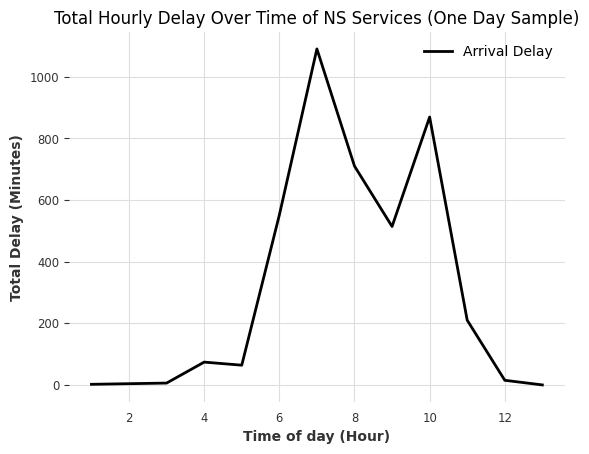

In [ ]:
# Aggregate arrival delay by hour (sum of arrival delay minutes for all trains on a given hour in a day)
df_aggregated = full_merged_dataset.groupby('hour')['Arrival Delay'].sum().reset_index()

# Create a TimeSeries from the aggregated DataFrame
total_hourly_delay_one_day = TimeSeries.from_dataframe(df_aggregated, time_col='hour', value_cols='Arrival Delay')

# Plot the aggregated delay time series
total_hourly_delay_one_day.plot();
plt.title("Total Hourly Delay Over Time of NS Services (One Day Sample)")
plt.xlabel("Time of day (Hour)")
plt.ylabel("Total Delay (Minutes)")
plt.show()


We see slight upward trend (most likely due to an increasing population) and a seasonality. In addition there's a drop near the end of the year, probably due to christmas break. There is also a strange peak near mid 2015, after further investigation we concluded that this was probably caused by natural disaster i.e. flooding and tornado, which caused and hoarding of supplies including food (https://en.wikipedia.org/wiki/2015_Texas%E2%80%93Oklahoma_flood_and_tornado_outbreak)

### Seasonality

In [ ]:
seasonality = check_seasonality(total_hourly_delay_one_day, max_lag=24)
seasonality

(True, np.int64(10))

Has a seasonality period of 10

### Stationary

In [ ]:
stationarity_test_kpss(total_hourly_delay_one_day, nlags=10)

(np.float64(0.4175076497950632),
 np.float64(0.06960877164005896),
 10,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

p >= 0.05, we do fail to reject the null hypothesis of stationarity. This suggests that the time series is stationary at 5% significance level.

(placeholder) p < 0.05, we reject the null hypothesis of stationarity. This suggests that the time series is non-stationary, and might need to apply techniques such as differencing or transformation to make it stationary before proceeding with further time series modeling (e.g., ARIMA).

### ACF

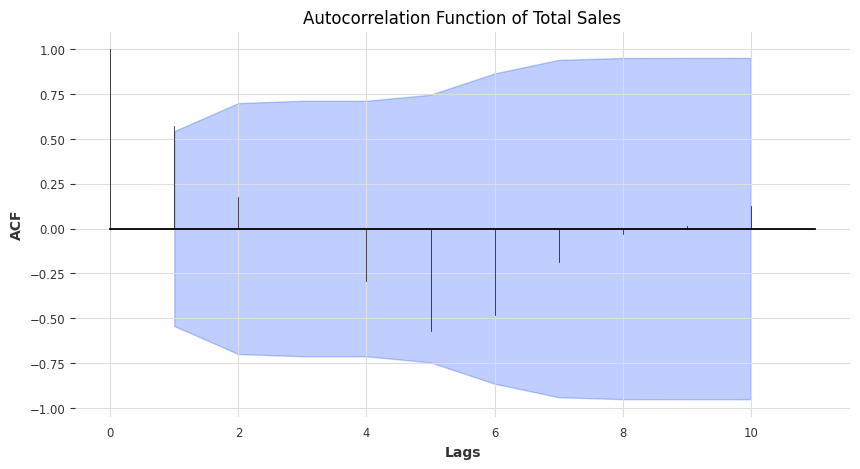

In [ ]:
plot_acf(total_hourly_delay_one_day, max_lag=10)

plt.title("Autocorrelation Function of Total Sales")
plt.xlabel("Lags")
plt.ylabel("ACF")

plt.show()

Shows highest correlation at lag 5

## Models Naive & XGB
2 rows in services for departure location and arrival location

Prediction Objectives: 
- for time horizon H (hour bin) will incoming train at station X be delayed or not?
- (regression) arrival delay

We want to predict for time horizon, we have set time horizon = 1 hour, so time_col = 

We want to predict the arrival delay duration (regression) so_value = 'Stop:Arrival delay'
We want to predict per arrival station so we group by 'Stop:Station code'

Encode Categorical Variables

In [ ]:
from darts.dataprocessing.transformers import StaticCovariatesTransformer

# Initialize the transformer
transformer = StaticCovariatesTransformer()

# Fit and transform the training data
series_train = transformer.fit_transform(series_train)

series_test = transformer.fit_transform(series_test)


In [ ]:
from darts.models import GlobalNaiveSeasonal, RandomForest, XGBModel, LightGBMModel

forecasts = {}

seasonality_period = 10

input_chunk_length = seasonality_period * 2
output_chunk_length = seasonality_period

random_state = 8

xgb_model = XGBModel(lags=seasonality_period, random_state = random_state)
naive_model = GlobalNaiveSeasonal(input_chunk_length=input_chunk_length, output_chunk_length=output_chunk_length)

naive_model.fit(series_train)
xgb_model.fit(series_train)


naive_forecast = [naive_model.predict(5, series=ts) for ts in series_train]
xgb_forecast = [xgb_model.predict(5, series=ts) for ts in series_train]


result_naive = pd.DataFrame()
result_xgb = pd.DataFrame()


for i, ts in enumerate(series_train):
    station_id = ts.static_covariates['id']

    naive_values = np.round(naive_forecast[i].values().flatten()).astype(int)
    xgb_values = np.round(xgb_forecast[i].values().flatten()).astype(int)

    result_naive = pd.concat([
        result_naive,
        pd.DataFrame({'id': station_id, **{f"F{i+1}": val for i, val in enumerate(naive_values)}})
    ])
    result_xgb = pd.concat([
        result_xgb,
        pd.DataFrame({'id': station_id, **{f"F{i+1}": val for i, val in enumerate(xgb_values)}})
    ])


result_naive.to_csv('result_naive.csv', index=False)
result_xgb.to_csv('result_xgb.csv', index=False)

In [ ]:

# Keep only relevant columns
df_sorted_agg = df_sorted[['Service:RDT-ID', 'Stop:Arrival delay', 'Stop:Arrival time']]

# Function to resample each service individually
def aggregate_5min(group, service_id):
    # Set datetime index for resampling
    group = group.set_index('Stop:Arrival time')
    # Resample to 5-minute intervals and take mean
    group_resampled = group.resample('5T').mean()
    # Forward-fill missing delays
    group_resampled['Stop:Arrival delay'] = group_resampled['Stop:Arrival delay'].fillna(method='ffill')
    # Reset index to keep datetime as a column
    group_resampled = group_resampled.reset_index()
    # Add service ID back
    group_resampled['Service:RDT-ID'] = service_id
    return group_resampled

# Apply to each service
df_list = []
for service_id, group in df_sorted_agg.groupby('Service:RDT-ID'):
    df_list.append(aggregate_5min(group, service_id))

# Combine all services back into a single DataFrame
df_agg = pd.concat(df_list, ignore_index=True)

print(df_agg.head())
print(df_agg.dtypes)

In [ ]:
split_index = int(len(df_sorted) * 0.8)
train_df = df_agg.iloc[:split_index].reset_index(drop=True)
test_df = df_agg.iloc[split_index:].reset_index(drop=True)


In [ ]:
series_train = TimeSeries.from_group_dataframe(
    train_df,
    time_col='Stop:Arrival time',
    value_cols='Stop:Arrival delay',
    group_cols='Service:RDT-ID',
    fill_missing_dates=True,  # fill gaps if any
    freq='5T'                 # explicitly tell Darts it's 5-minute intervals
)

series_test = TimeSeries.from_group_dataframe(
    test_df,
    time_col='Stop:Arrival time',
    value_cols='Stop:Arrival delay',
    group_cols='Service:RDT-ID',
    fill_missing_dates=True,  # fill gaps if any
    freq='5T'                 # explicitly tell Darts it's 5-minute intervals
)

## GNN
Some graph libraries
https://pyg.org/
https://www.dgl.ai/


Look further into graph construction of existing work

IDEA (master node): can we utilize subgraphs as additional Context Vector (i.e. master nodes) utilizing the station classification (making multiple subgraphs of > major stations 'type' classification, assumption is that the graph connectivity stays the same; so given a node we could utilize the nearest neighbours of these subgraphs as additional feature/signals)

Node = stations (+ but also trains moving in between nodes? -> hetero graph)
Edge = lines (but does not represent # of rail tracks, so how to model # of lines? or just '1 shared railline')
Graph level = train railnetwork (include utilized by NS only? how? from to station data? or like jonathans official rail network (is there an alternative)?)
Master node/Context vector -> can we make a subgraph as proxy master node capturing different info than everything? maybe only large station nodes and intercity lines?

De stations in deze dataset worden gebruikt door de Rijden de Treinen website en app. De bron voor deze data is NS; de stations worden direct uit de NS API gehaald. De stationsnamen, geocoördinaten en stationcodes worden bepaald door NS.

rdt_id/id = intern RdT ID

code stationsnaam code max 8 chars, NS/prorail code

UIC code (international id station code), nl stations have 84 prefix

name_short korte station
name_medium
name_long full station name

slug = uniek small case, no space, consistent w RdT stationspage

type = Het soort station. Mogelijke waarden zijn (van groot naar klein station): megastation, knooppuntIntercitystation, intercitystation, knooppuntSneltreinstation, sneltreinstation, knooppuntStoptreinstation, stoptreinstation, facultatiefStation. De categorie knooppunt impliceert dat deze stations bedoeld zijn voor het overstappen op een andere trein. Een facultatiefStation is een station waar normaal gesproken geen treinen stoppen, behalve bij speciale gelegenheden (zoals voetbalwedstrijden).


Check the following for EDA on stations: different kind of stations
KnooppuntStation
Facultiefstation
check Knooppunt
Station coverage (i.e. which stations have the most # of trains stopping/crossing)

Check whether all stations are covered by atleast one train/service (per year?)

Filter on NL, for double check

geo_lat, latitude degree
geo_lng, longitude degree

